In [95]:
import matplotlib.pyplot as plt
import numpy as np
from keras.models import Sequential
from keras.layers import Input, Dense
from keras.datasets import california_housing
from keras import callbacks
from keras.src.layers import Dropout

(inputs, targets), (x_test, y_test) = california_housing.load_data(version='large', 
                                        test_split=0.2)
print(inputs.shape, targets.shape)
print(x_test.shape, y_test.shape)

(16512, 8) (16512,)
(4128, 8) (4128,)


In [96]:
# Extract sets for training and validation
x_train = inputs[:11000]
y_train = targets[:11000]
x_val = inputs[11000:]
y_val = targets[11000:]

In [97]:
mean = x_train.mean(axis=0) # mean and standard deviation computed from training set only
std = x_train.std(axis=0)
x_train -= mean
x_train /= std
x_test -= mean
x_test /= std
x_val -= mean
x_val /= std
y_train /= 1e5
y_test /= 1e5
y_val /= 1e5

Training a model that starts overfitting at ~ epoch 100:

In [98]:
# define the model architecture
model = Sequential([
    Input(shape=(8,)),
    Dense(256, activation='relu'),
    Dense(256, activation='relu'),
    Dense(1)
    ])

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=100,
    restore_best_weights=True
)

# configure the learning algorithm
model.compile(optimizer='adam',loss='mse',metrics=['mae'])

In [99]:
history = model.fit(x_train, y_train, epochs=500, batch_size=32, validation_data=(x_val, y_val), verbose=1, callbacks=early_stop)

Epoch 1/500
344/344 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.6068 - mae: 0.5393 - val_loss: 0.3822 - val_mae: 0.4443
Epoch 2/500
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3859 - mae: 0.4416 - val_loss: 0.3429 - val_mae: 0.4158
Epoch 3/500
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3548 - mae: 0.4214 - val_loss: 0.3332 - val_mae: 0.4056
Epoch 4/500
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3450 - mae: 0.4157 - val_loss: 0.3263 - val_mae: 0.4063
Epoch 5/500
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3286 - mae: 0.4022 - val_loss: 0.3056 - val_mae: 0.3777
Epoch 6/500
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3151 - mae: 0.3922 - val_loss: 0.3354 - val_mae: 0.4178
Epoch 7/500
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3162 - mae: 0.3947 - val_loss: 0.3060 - val_mae: 0.3902
Epoch 8/500
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3075 - mae: 0.3848 - val_loss: 0.3056 - val_mae: 0.3740
Epoch 9/500
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/

Text(0, 0.5, 'Loss')

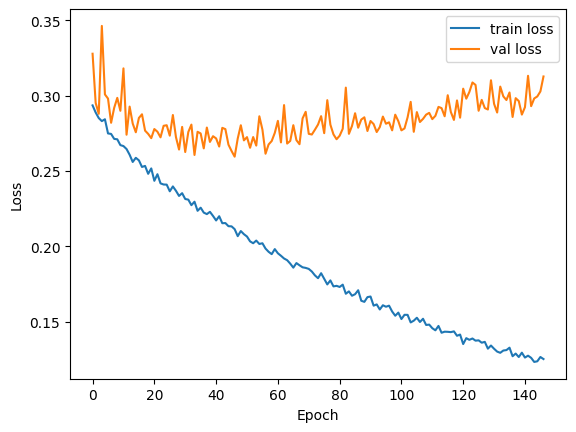

In [100]:
plt.plot(history.history['loss'][10:], label='train loss')
plt.plot(history.history['val_loss'][10:], label='val loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')

Training new model with both training and validation sets combined along with regularisation. Training loss stops at ~ epoch 140 so we'll stop at 200:

In [110]:
from keras.src.regularizers import regularizers
from keras.src.layers import BatchNormalization

x_train_full = np.concatenate((x_train, x_val), axis=0) # join train + val sets
y_train_full = np.concatenate((y_train, y_val), axis=0)

model = Sequential([
    Input(shape=(8,)),
    Dense(256, activation='relu'),
    Dense(256, activation='relu', kernel_regularizer=regularizers.L2(1e-4)),
    Dropout(0.2),
    Dense(1)
    ])

model.compile(optimizer='adam',loss='mse',metrics=['mae'])
history_2 = model.fit(x_train_full, y_train_full, epochs=200, batch_size=32, verbose=1)

Epoch 1/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.5976 - mae: 0.5259
Epoch 2/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4158 - mae: 0.4476
Epoch 3/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3865 - mae: 0.4289
Epoch 4/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3723 - mae: 0.4183
Epoch 5/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3559 - mae: 0.4077
Epoch 6/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3483 - mae: 0.4024
Epoch 7/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3411 - mae: 0.3966
Epoch 8/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3363 - mae: 0.3953
Epoch 9/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3303 - mae: 0.3896
Epoch 10/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3280 - mae: 0.3870
Epoch 11/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3197 - mae: 0.3836
Epoch 12/200
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3161 - mae: 0.3803
Epoch 13/200


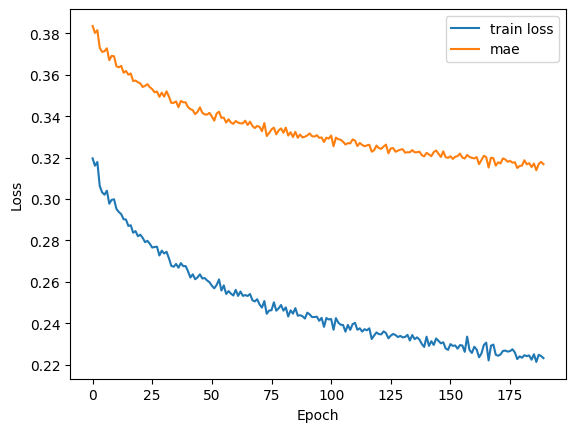

In [111]:
plt.plot(history_2.history['loss'][10:], label='train loss')
plt.plot(history_2.history['mae'][10:], label='mae')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [112]:
test_loss, test_mae = model.evaluate(x_test, y_test)
print(f'Test mean absolute error: {test_mae:.4f}')

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2719 - mae: 0.3339
Test mean absolute error: 0.3339


Adding regularisation using Dropout-layer and L2-regularisation, test MAE reduced from 0.35 to 0.33. 

Putting dropout after first layer was not as effective as placing it at the end. Dropping 20% of weights seems to be best in this case. Dropping 50% increased MAE instead. Batch normalization did not seem to have a great effect. 

L2 regularisation on the first layer was not effective, but seemed to work okay when on the second layer.

In [113]:
from keras.losses import MeanAbsoluteError

y_pred_baseline = np.full_like(y_test, np.mean(y_train_full, axis=0))
mae_fn = MeanAbsoluteError()
mae_baseline = mae_fn(y_test, y_pred_baseline).numpy()
print(f'Mean baseline MAE: {mae_baseline:.4f}')

Mean baseline MAE: 0.9059
